In [8]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

csv_path = 'project-1-at-2026-01-27-05-06-e12e4e5a.csv'
df = pd.read_csv(csv_path, dtype={'tweet_id': str}, low_memory=False)
print('Rows:', len(df))
df.head()

Rows: 229


,annotation_id,annotator,created_at,favorite_count,followers_count,following_count,full_text,hashtags,id,is_blue_verified,...,total_tweets_by_user,tweet_id,updated_at,urls,user_desc,user_id,user_location,user_name,user_verified,view_count
0,11,6,2026-01-20T14:22:59.630701Z,702,1007659,883,"திருப்பூர் மாவட்டம் இடுவாய் கிராமத்தில், பொதும...",[],1,True,...,18062,2001628639356711363,2026-01-20T14:22:59.630727Z,[],அறம் செய்ய விரும்பு. BJP Karyakartha.,61121030,India,K.Annamalai,False,5588
1,12,6,2026-01-20T14:25:20.509030Z,60378,5519898,1,"Thank you Erode 🙏🏻 <a href=""https://t.co/897AD...",[],2,True,...,433,2001562955176120490,2026-01-20T14:25:20.509051Z,[],Official Page handled by Office of Actor Vijay,1156338067,NaN,Vijay,False,832866
2,13,6,2026-01-20T14:27:36.024833Z,1248,35077,244,நடிகனுக்கு ஜால்ரா அடித்து வாங்கும் பதவி என் மய...,[],3,True,...,1852,2001507639835132078,2026-01-20T14:27:36.024855Z,[],"Action Director, Actor & State President-Art a...",1166196738,"Chennai, India",Kanal V Kannan,False,10958
3,104,3,2026-01-23T07:51:50.589081Z,3083,4000735,91,"Hon'ble PM Thiru. @NarendraModi, Tamil Nadu is...",[],4,True,...,11099,2001464934690099643,2026-01-23T07:51:50.589115Z,[],Chief Minister of Tamil Nadu | President of th...,2163039523,NaN,M.K.Stalin - தமிழ்நாட்டை தலைகுனிய விடமாட்டேன்,False,71916
4,15,6,2026-01-20T14:32:44.022103Z,1074,1993,2016,நாம் தமிழர் பிள்ளைகள் சேலம் மாவட்டம் தரமான சம்...,[],5,True,...,12502,2001547505054761159,2026-01-20T14:32:44.022125Z,[],private,1105332988223471616,chennai,ஆறுமுகம்,False,7179


In [9]:
df.columns

Index(['annotation_id', 'annotator', 'created_at', 'favorite_count',
       'followers_count', 'following_count', 'full_text', 'hashtags', 'id',
       'is_blue_verified', 'is_news', 'is_political', 'is_quote', 'lang',
       'lead_time', 'link', 'overall_sentiment', 'party_list', 'place',
       'possibly_sensitive', 'quote_count', 'reply_count', 'retweet_count',
       'sarcasm_check', 'screen_name', 'stance_admk', 'stance_bjp',
       'stance_congress', 'stance_dmk', 'stance_ntk', 'stance_tvk',
       'total_tweets_by_user', 'tweet_id', 'updated_at', 'urls', 'user_desc',
       'user_id', 'user_location', 'user_name', 'user_verified', 'view_count'],
      dtype='str')

In [11]:
# Parse datetimes, convert to IST, and compute tweet length
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
# convert UTC timestamps to India timezone (Asia/Kolkata)
df['created_at_ist'] = df['created_at'].dt.tz_convert('Asia/Kolkata')
df['hour_ist'] = df['created_at_ist'].dt.hour
df['tweet_len'] = df['full_text'].astype(str).str.len()
df[['created_at','created_at_ist','hour_ist','tweet_len']].head()

,created_at,created_at_ist,hour_ist,tweet_len
0,2026-01-20 14:22:59.630701+00:00,2026-01-20 19:52:59.630701+05:30,19,1275
1,2026-01-20 14:25:20.509030+00:00,2026-01-20 19:55:20.509030+05:30,19,80
2,2026-01-20 14:27:36.024833+00:00,2026-01-20 19:57:36.024833+05:30,19,235
3,2026-01-23 07:51:50.589081+00:00,2026-01-23 13:21:50.589081+05:30,13,330
4,2026-01-20 14:32:44.022103+00:00,2026-01-20 20:02:44.022103+05:30,20,160


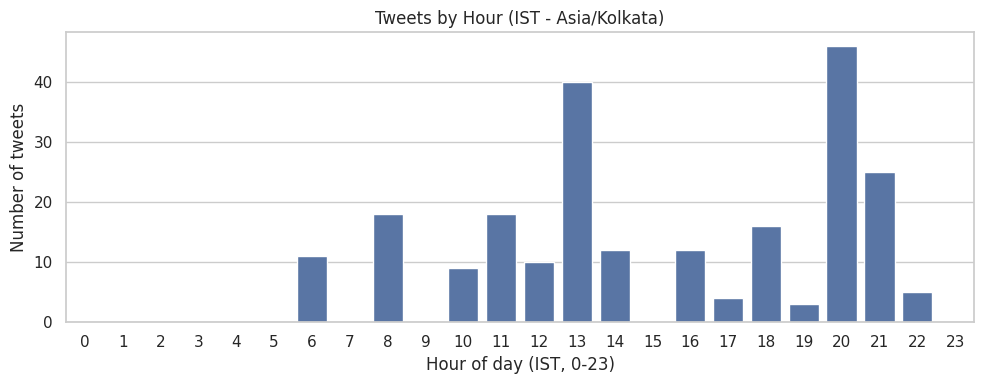

In [3]:
# Histogram of tweets by hour (converted to IST)
plt.figure(figsize=(10,4))
sns.countplot(x='hour_ist', data=df, order=list(range(24)), color='C0')
plt.title('Tweets by Hour (IST - Asia/Kolkata)')
plt.xlabel('Hour of day (IST, 0-23)')
plt.ylabel('Number of tweets')
plt.tight_layout()
plt.show()

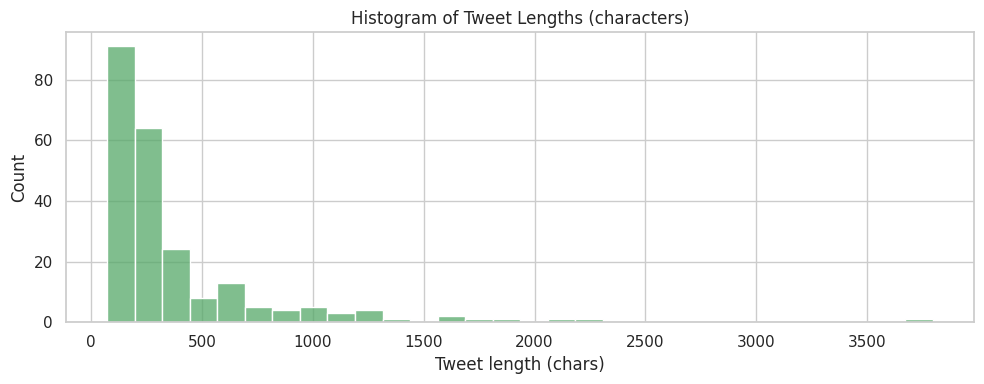

count     229.000000
mean      378.231441
std       427.968348
min        73.000000
25%       152.000000
50%       231.000000
75%       338.000000
max      3796.000000
Name: tweet_len, dtype: float64

In [12]:
# Histogram of tweet lengths
plt.figure(figsize=(10,4))
sns.histplot(df['tweet_len'].dropna(), bins=30, color='C2')
plt.title('Histogram of Tweet Lengths (characters)')
plt.xlabel('Tweet length (chars)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

df['tweet_len'].describe()


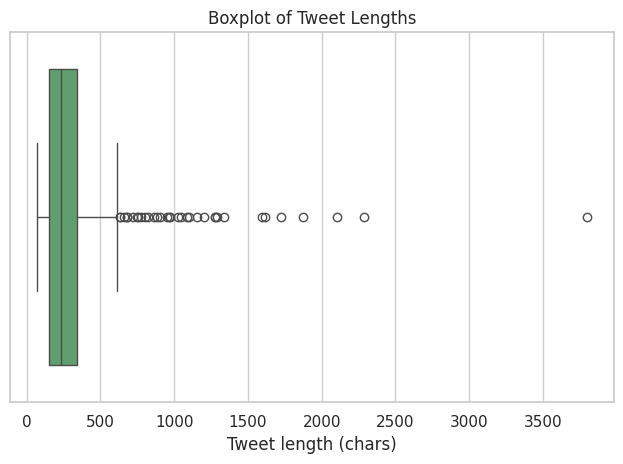

In [13]:
sns.boxplot(x=df['tweet_len'], color='C2')
plt.title('Boxplot of Tweet Lengths')
plt.xlabel('Tweet length (chars)')
plt.tight_layout()
plt.show()

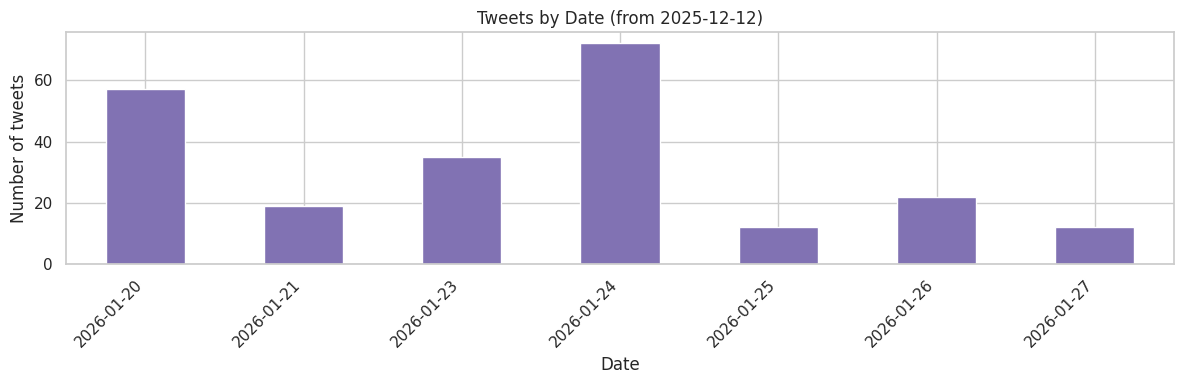

In [7]:
# Histogram of tweets by date
start = pd.to_datetime('2025-12-12', utc=True)
mask = df['created_at'].notna() #& (df['created_at'] >= start)
df_from = df.loc[mask].copy()
df_from['date'] = df_from['created_at'].dt.date
counts = df_from.groupby('date').size().sort_index()
plt.figure(figsize=(12,4))
counts.plot(kind='bar', color='C4')
plt.title('Tweets by Date (from 2025-12-12)')
plt.xlabel('Date')
plt.ylabel('Number of tweets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Political file rows: 229


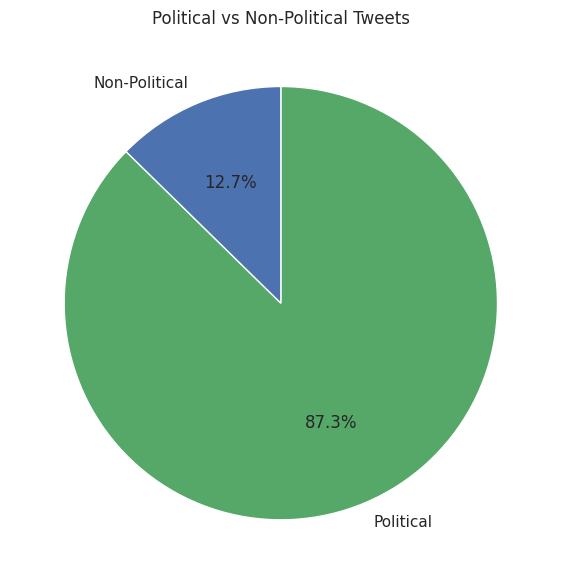

No. of political tweets: 200
No. of Non-Political tweets: 29
Total No. of Tweets: 229


In [34]:
# Load political annotation CSV and summarize
pol_path = 'data/tweet_is_political_2026-02-15.csv'
df_pol = pd.read_csv(pol_path, low_memory=False)
print('Political file rows:', len(df_pol))
df_pol.head()

# Normalize labels to Political / Non-Political
pol_label = df_pol['is_political'].astype(str).str.strip().str.lower().map(lambda x: 'Political' if x in ['yes','true','1'] else 'Non-Political')
counts = pol_label.value_counts()
total = len(pol_label)

# Pie chart for political vs non-political
plt.figure(figsize=(6,6))
counts.plot.pie(autopct='%1.1f%%', colors=['C2','C0'], startangle=90, counterclock=False)
plt.title('Political vs Non-Political Tweets')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Print numeric summary
print('No. of political tweets:', int(counts.get('Political', 0)))
print('No. of Non-Political tweets:', int(counts.get('Non-Political', 0)))
print('Total No. of Tweets:', int(total))

Party-mention file rows: 1200


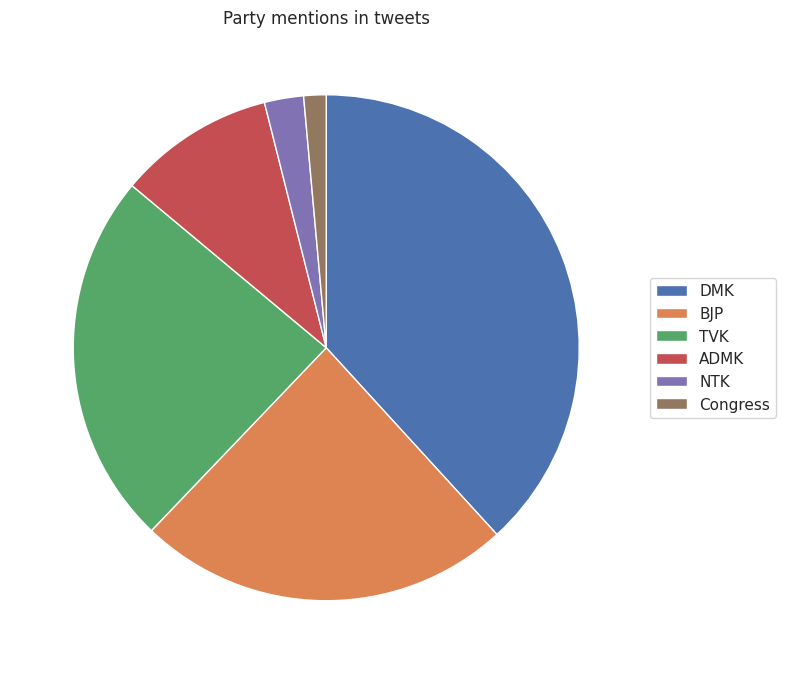

Party mention counts and percentages:
DMK: 107 (38.2%)
BJP: 67 (23.9%)
TVK: 67 (23.9%)
ADMK: 28 (10.0%)
NTK: 7 (2.5%)
Congress: 4 (1.4%)
Total party mentions: 280


In [35]:
# Load party mention CSV and summarize
party_path = 'data/tweet_party_mention_2026-02-15.csv'
df_party = pd.read_csv(party_path, low_memory=False)
print('Party-mention file rows:', len(df_party))
df_party.head()

# Ensure is_mentioned is numeric and aggregate by Party
df_party['is_mentioned'] = pd.to_numeric(df_party['is_mentioned'], errors='coerce').fillna(0).astype(int)
party_counts = df_party.groupby('Party')['is_mentioned'].sum().sort_values(ascending=False)
party_counts = party_counts[party_counts > 0]

# Pie chart of party mentions 
plt.figure(figsize=(8,8))
wedges, texts = plt.pie(party_counts, startangle=90, counterclock=False)
plt.title('Party mentions in tweets')
plt.ylabel('')
plt.legend(labels=party_counts.index.tolist(), loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# Print counts and percentages as text output
total = int(party_counts.sum())
print('Party mention counts and percentages:')
for party, cnt in party_counts.items():
    pct = cnt / total * 100 if total > 0 else 0.0
    print(f'{party}: {int(cnt)} ({pct:.1f}%)')
print('Total party mentions:', total)